In [1]:
import h5py

filename = r'data\Cross\train\rest_113922_1.h5'
with h5py.File(filename, 'r') as f:
    keys = list(f.keys())
    assert len(keys) == 1, f"too many or few keys found ({keys})"
    # # Access a specific dataset
    # # f['dataset_name'] returns an HDF5 dataset object
    dataset = f[keys[0]][()]
    print(dataset.shape)

(248, 35624)


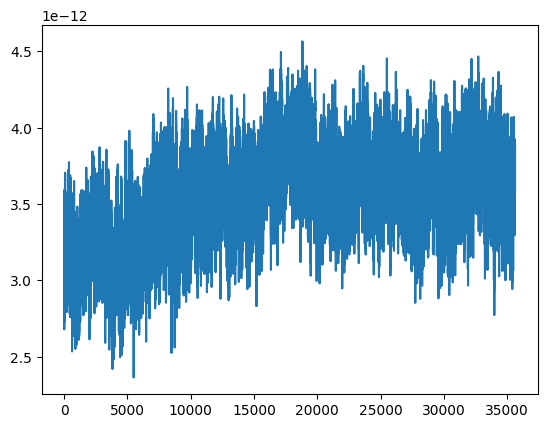

In [2]:
import matplotlib.pyplot as plt

single_sensor = dataset[0, :]

plt.plot(single_sensor)
plt.show()

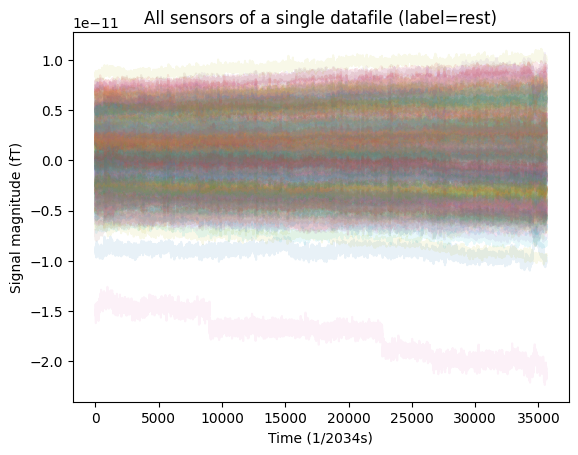

In [5]:
for i in range(dataset.shape[0]):
    # avg = dataset[i].mean()
    # if avg < -1e-11:
    #     plt.plot(dataset[i], label=i, alpha=0.1)
    # else:
    plt.plot(dataset[i], alpha=0.1)

# plt.legend(loc="lower left")
plt.ylabel("Signal magnitude (fT)")
plt.xlabel("Time (1/2034s)")
plt.title(f"All sensors of a single datafile (label={filename.split('\\')[-1].split('_')[0]})")

plt.show()

# view of 1 dataset window

In [5]:
# pip install seaborn

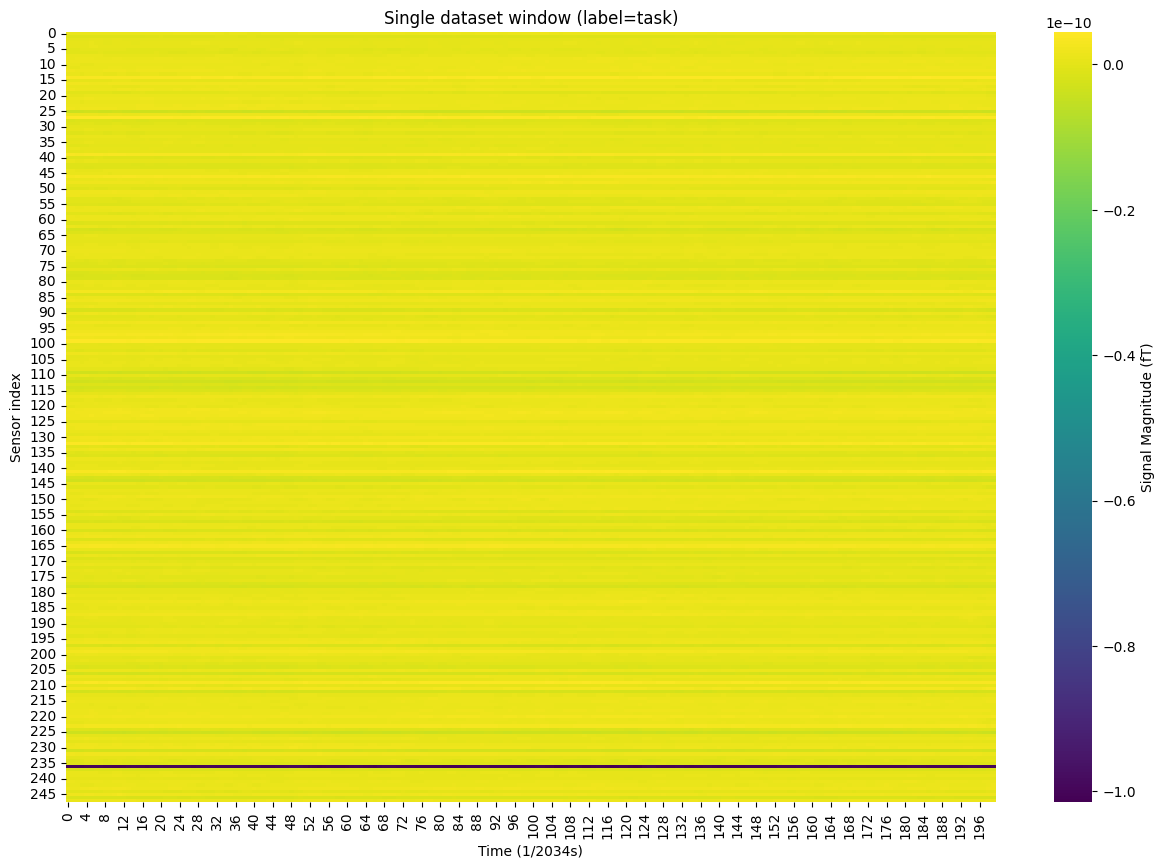

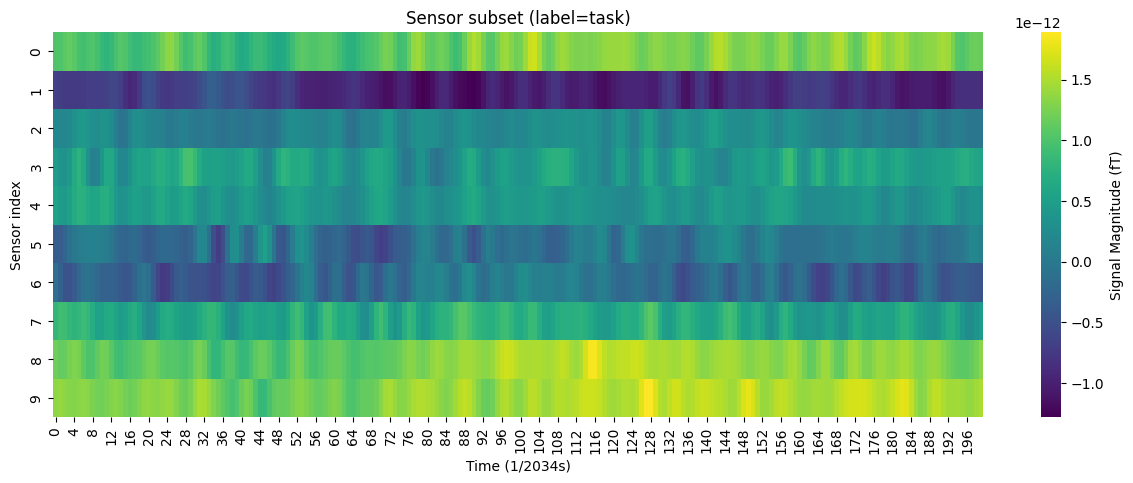

In [6]:
import seaborn as sns

window_size = 200
window = dataset[:, :window_size]

plt.figure(figsize=(15, 10))
sns.heatmap(window, cmap='viridis', cbar_kws={'label': 'Signal Magnitude (fT)'})
plt.ylabel("Sensor index")
plt.xlabel("Time (1/2034s)")
plt.title(f"Single dataset window (label={filename.split('\\')[-1].split('_')[0]})")
plt.show()

plt.figure(figsize=(15, 5))
sns.heatmap(window[:10, :], cmap='viridis', cbar_kws={'label': 'Signal Magnitude (fT)'})
plt.ylabel("Sensor index")
plt.xlabel("Time (1/2034s)")
plt.title(f"Sensor subset (label={filename.split('\\')[-1].split('_')[0]})")
plt.show()


In [7]:
from meg_dataset import MEGDataset
from main import DATASET_MAPPING

dataset = MEGDataset(
    data_dirs=DATASET_MAPPING["intra"]["train"].replace("assignment_2/", ""),
    window_size=200,
    stride=50,
    downsample_factor=4,
    lazy=True,
)

dataset

c:\Users\joris\miniconda3\envs\INFOMDLR\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MEGDataset(n_files=32, n_windows=5600, window_size=200, stride=50, downsample_factor=4, lazy=True)

In [8]:
counts = [0, 0, 0, 0]
for element in dataset:
    counts[element[1]] += 1
counts 

[1400, 1400, 1400, 1400]

In [9]:
from sklearn.model_selection import train_test_split

indices = list(range(len(dataset)))
    
######################### Split the data. ##########################
train_idx, val_idx = train_test_split(
    indices, 
    test_size=0.2,
    random_state=42
)

dataset.fit_normalisation(train_idx)

counts = [0, 0, 0, 0]
for element in dataset:
    counts[element[1]] += 1
counts 

[1400, 1400, 1400, 1400]